# Hierárquico e DBSCAN

**Tema:** Aprendizado Não Supervisionado › Clustering

Dois algoritmos que não pensam em "centros". O hierárquico aglomerativo
funde os grupos mais próximos, um par por vez, e registra a árvore
inteira; o DBSCAN define grupo como região densa e aceita que alguns
pontos não pertençam a grupo nenhum. Implementamos os dois do zero em
versões pequenas e comparamos com `scipy`/`scikit-learn`.

In [1]:
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import DBSCAN, HDBSCAN, AgglomerativeClustering, KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(52)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
CORES = np.array([AZUL, VERMELHO, VERDE, ROXO, AMBAR, "#5A5A5A", "#2A9D8F", "#E76F51"])
print("pronto")

pronto


## 1. Aglomerativo do zero (single e complete linkage)

Versão direta, $O(n^3)$, só para entender: a cada passo, calcular a
distância entre todos os pares de grupos e fundir o par mais próximo.

In [2]:
def aglomerativo_do_zero(X, ligacao="single"):
    D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=2))
    grupos = [[i] for i in range(len(X))]
    alturas = []
    agrega = np.min if ligacao == "single" else np.max
    while len(grupos) > 1:
        melhor = (np.inf, None, None)
        for a in range(len(grupos)):
            for b in range(a + 1, len(grupos)):
                d = agrega(D[np.ix_(grupos[a], grupos[b])])
                if d < melhor[0]:
                    melhor = (d, a, b)
        d, a, b = melhor
        alturas.append(d)
        grupos[a] = grupos[a] + grupos[b]
        del grupos[b]
    return np.array(alturas)


P, _ = make_blobs(n_samples=25, centers=3, cluster_std=1.0, random_state=4)
for lig in ["single", "complete"]:
    nossas = aglomerativo_do_zero(P, lig)
    scipy_alt = linkage(P, method=lig)[:, 2]
    print(f"{lig:>8s}: alturas de fusão iguais às do scipy? {np.allclose(nossas, scipy_alt)}"
          f"  | últimas 3 fusões: {np.round(nossas[-3:], 2)}")

  single: alturas de fusão iguais às do scipy? True  | últimas 3 fusões: [1.93 2.02 6.52]
complete: alturas de fusão iguais às do scipy? True  | últimas 3 fusões: [ 3.91  6.41 14.43]


## 2. Dendrograma e corte

O salto grande nas últimas fusões indica onde cortar: fundir grupos que
estavam longe custa muito mais que as fusões anteriores.

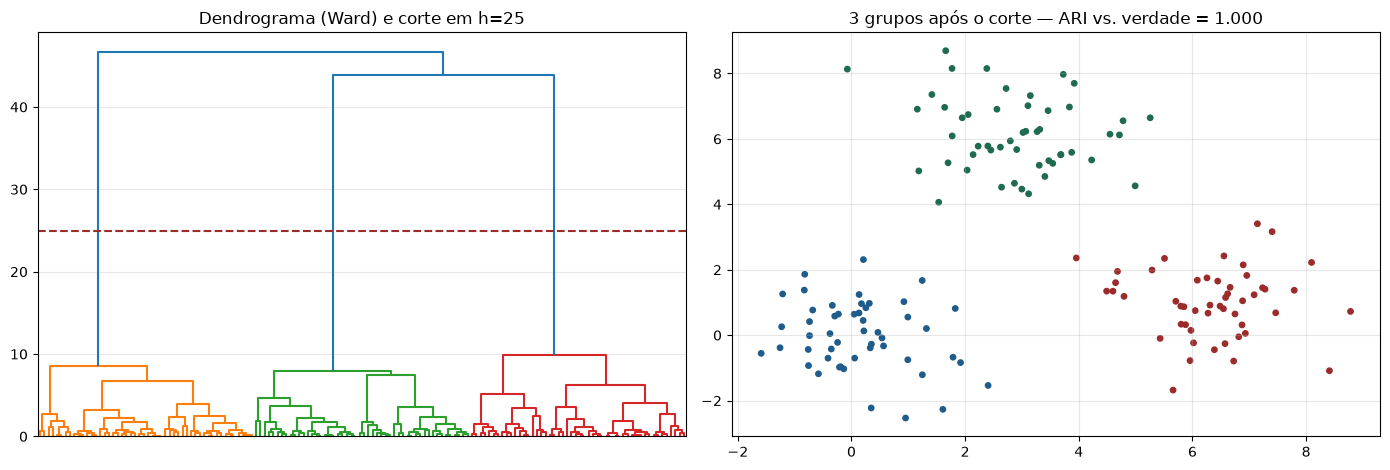

alturas das 6 últimas fusões: [ 7.4  7.9  8.5  9.8 43.9 46.7]


In [3]:
Xh, yh = make_blobs(n_samples=150, centers=[[0, 0], [6, 1], [3, 6]], cluster_std=1.1,
                    random_state=1)
Z = linkage(Xh, method="ward")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))
dendrogram(Z, ax=ax1, no_labels=True, color_threshold=25)
ax1.axhline(25, color=VERMELHO, ls="--"); ax1.set_title("Dendrograma (Ward) e corte em h=25")
rot = fcluster(Z, t=25, criterion="distance")
ax2.scatter(Xh[:, 0], Xh[:, 1], c=CORES[rot - 1], s=15)
ax2.set_title(f"{len(np.unique(rot))} grupos após o corte — ARI vs. verdade = "
              f"{adjusted_rand_score(yh, rot):.3f}")
plt.tight_layout(); plt.show()
print("alturas das 6 últimas fusões:", np.round(Z[-6:, 2], 1))

## 3. Ligações comparadas: quando o single vence e quando ele desaba

Nas luas, a ligação single acompanha a forma curva. Em blobs ligados por
uma "ponte" de poucos pontos, o single encadeia tudo num grupo só.

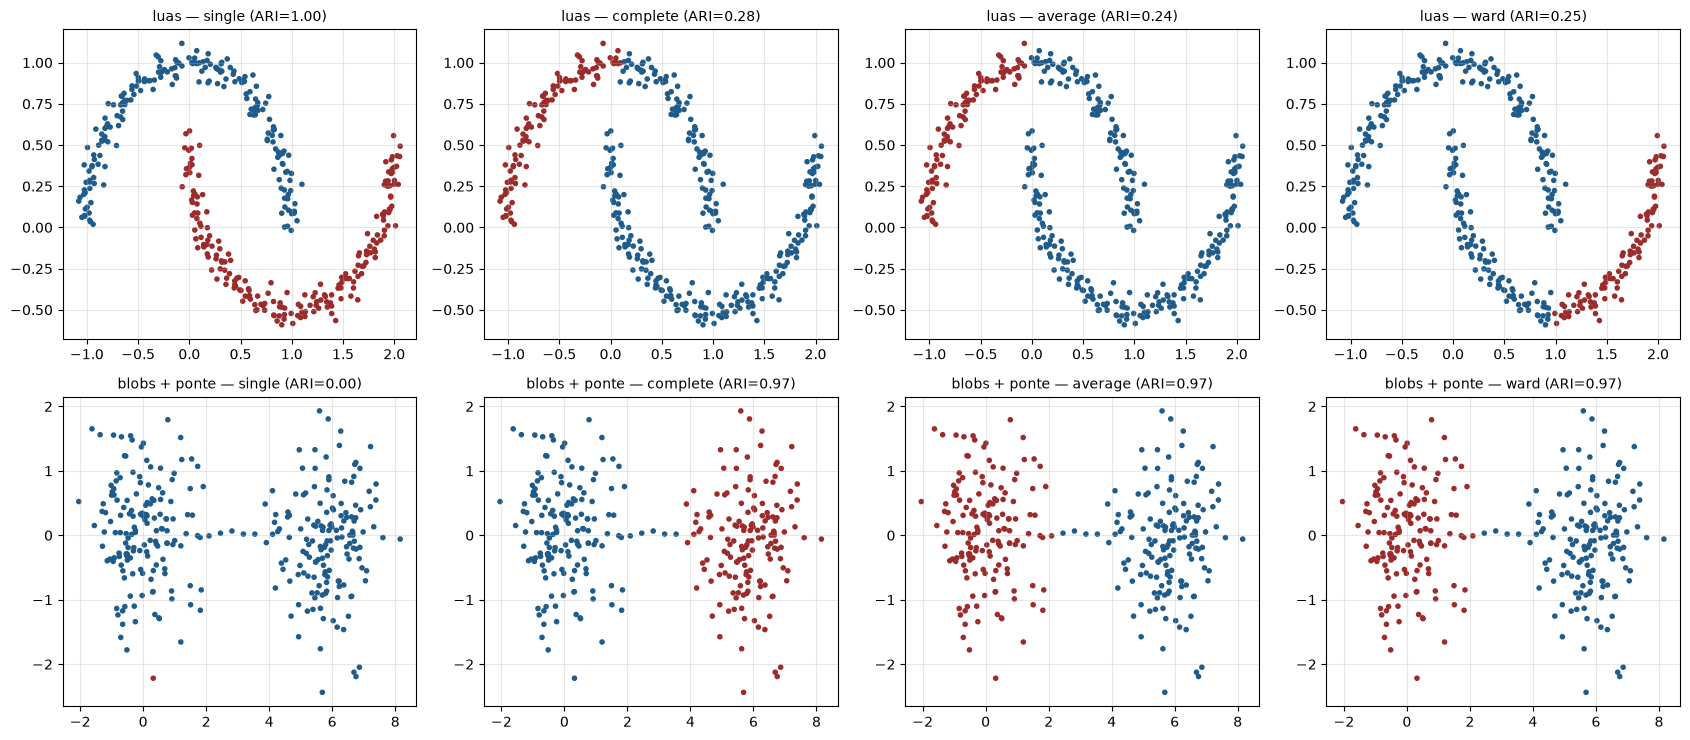

In [4]:
luas, y_luas = make_moons(n_samples=400, noise=0.05, random_state=0)
blobs, y_blobs = make_blobs(n_samples=300, centers=[[0, 0], [6, 0]], cluster_std=0.8,
                            random_state=0)
ponte = np.column_stack([np.linspace(1, 5, 12), rng.normal(0, 0.1, 12)])
blobs_ponte = np.vstack([blobs, ponte])
y_ponte = np.concatenate([y_blobs, (ponte[:, 0] > 3).astype(int)])

fig, axes = plt.subplots(2, 4, figsize=(17, 7.5))
for linha, (D, yv, nome) in enumerate([(luas, y_luas, "luas"),
                                       (blobs_ponte, y_ponte, "blobs + ponte")]):
    for col, lig in enumerate(["single", "complete", "average", "ward"]):
        r = AgglomerativeClustering(n_clusters=2, linkage=lig).fit_predict(D)
        axes[linha, col].scatter(D[:, 0], D[:, 1], c=CORES[r], s=9)
        axes[linha, col].set_title(f"{nome} — {lig} (ARI={adjusted_rand_score(yv, r):.2f})",
                                   fontsize=10)
plt.tight_layout(); plt.show()

## 4. DBSCAN do zero

Três passos: marcar os pontos-núcleo, expandir cada grupo a partir de um
núcleo por busca em largura (só núcleos propagam), e deixar como ruído
(-1) quem não foi alcançado.

In [5]:
def dbscan_do_zero(X, eps, min_samples):
    viz = NearestNeighbors(radius=eps).fit(X).radius_neighbors(X, return_distance=False)
    nucleo = np.array([len(v) >= min_samples for v in viz])
    rotulos = np.full(len(X), -1)
    grupo = 0
    for i in range(len(X)):
        if not nucleo[i] or rotulos[i] != -1:
            continue
        fila = deque([i])
        rotulos[i] = grupo
        while fila:
            atual = fila.popleft()
            if not nucleo[atual]:
                continue  # ponto de borda: entra no grupo, mas não propaga
            for vizinho in viz[atual]:
                if rotulos[vizinho] == -1:
                    rotulos[vizinho] = grupo
                    fila.append(vizinho)
        grupo += 1
    return rotulos, nucleo


x1d = np.array([1, 1.5, 2, 2.2, 5, 8, 8.3, 8.5]).reshape(-1, 1)
rot1d, nuc1d = dbscan_do_zero(x1d, eps=0.6, min_samples=3)
print(pd.DataFrame({"x": x1d.ravel(), "núcleo": nuc1d, "grupo": rot1d}).to_string(index=False))

luas_p = StandardScaler().fit_transform(luas)
nosso, _ = dbscan_do_zero(luas_p, eps=0.3, min_samples=8)
sk = DBSCAN(eps=0.3, min_samples=8).fit_predict(luas_p)
print(f"\nluas — mesma partição que o sklearn? ARI = {adjusted_rand_score(nosso, sk):.3f}")

  x  núcleo  grupo
1.0   False      0
1.5    True      0
2.0    True      0
2.2   False      0
5.0   False     -1
8.0    True      1
8.3    True      1
8.5    True      1

luas — mesma partição que o sklearn? ARI = 1.000


O exemplo 1D reproduz o `teoria.pdf`: dois grupos e o ponto 5 como ruído.
(Pontos de borda alcançáveis por dois grupos podem ser atribuídos a um ou
outro conforme a ordem de visita — a única fonte de não-determinismo do
DBSCAN.)

## 5. Escolhendo eps pelo gráfico da k-distância

eps=0.1: 15 grupos, 63.5% ruído, ARI=0.016
eps=0.2: 2 grupos,  0.8% ruído, ARI=0.985
eps=0.3: 2 grupos,  0.0% ruído, ARI=1.000
eps=0.5: 2 grupos,  0.0% ruído, ARI=1.000
eps=0.8: 1 grupos,  0.0% ruído, ARI=0.000


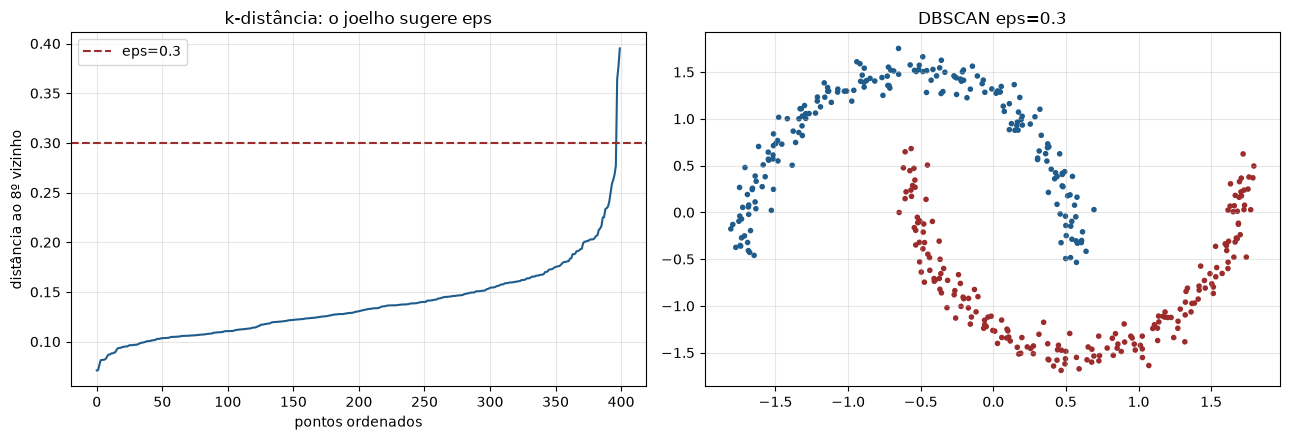

In [6]:
k = 8
dist_k = np.sort(NearestNeighbors(n_neighbors=k).fit(luas_p).kneighbors(luas_p)[0][:, -1])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(dist_k, color=AZUL)
ax1.axhline(0.3, color=VERMELHO, ls="--", label="eps=0.3")
ax1.set_xlabel("pontos ordenados"); ax1.set_ylabel(f"distância ao {k}º vizinho")
ax1.set_title("k-distância: o joelho sugere eps"); ax1.legend()
for eps in [0.1, 0.2, 0.3, 0.5, 0.8]:
    r = DBSCAN(eps=eps, min_samples=k).fit_predict(luas_p)
    print(f"eps={eps:.1f}: {len(set(r)) - (1 if -1 in r else 0)} grupos, "
          f"{np.mean(r == -1):5.1%} ruído, ARI={adjusted_rand_score(y_luas, r):.3f}")
r = DBSCAN(eps=0.3, min_samples=k).fit_predict(luas_p)
ax2.scatter(luas_p[:, 0], luas_p[:, 1], s=9, c=np.where(r >= 0, CORES[r % 8], "#BBBBBB"))
ax2.set_title("DBSCAN eps=0.3")
plt.tight_layout(); plt.show()

## 6. Densidades diferentes: DBSCAN falha, HDBSCAN resolve

Um grupo compacto, um médio e um espalhado. Não existe um único eps que
sirva para os três.

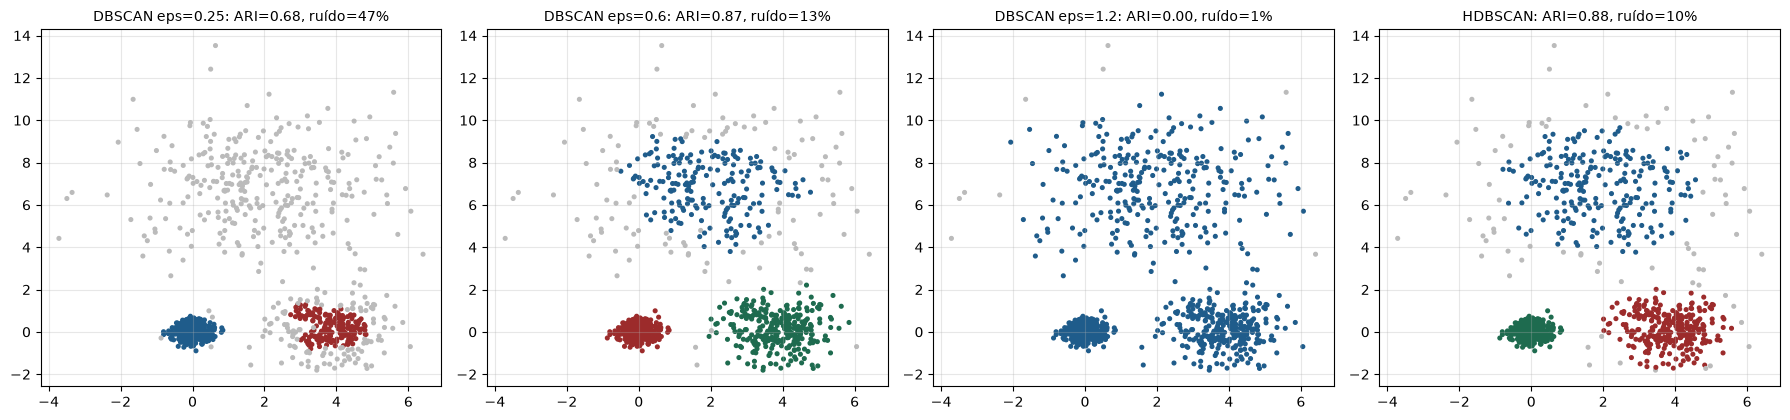

In [7]:
dens, y_dens = make_blobs(n_samples=[300, 300, 300], centers=[[0, 0], [4, 0], [2, 7]],
                          cluster_std=[0.3, 0.8, 1.8], random_state=3)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.3))
for ax, eps in zip(axes[:3], [0.25, 0.6, 1.2]):
    r = DBSCAN(eps=eps, min_samples=10).fit_predict(dens)
    ax.scatter(dens[:, 0], dens[:, 1], s=7, c=np.where(r >= 0, CORES[r % 8], "#BBBBBB"))
    ax.set_title(f"DBSCAN eps={eps}: ARI={adjusted_rand_score(y_dens, r):.2f}, "
                 f"ruído={np.mean(r == -1):.0%}", fontsize=10)
r = HDBSCAN(min_cluster_size=30, copy=True).fit_predict(dens)
axes[3].scatter(dens[:, 0], dens[:, 1], s=7, c=np.where(r >= 0, CORES[r % 8], "#BBBBBB"))
axes[3].set_title(f"HDBSCAN: ARI={adjusted_rand_score(y_dens, r):.2f}, "
                  f"ruído={np.mean(r == -1):.0%}", fontsize=10)
plt.tight_layout(); plt.show()

**Leitura esperada:** eps pequeno transforma o grupo espalhado em ruído;
eps grande começa a fundir os grupos compactos. HDBSCAN, que considera
todas as densidades ao mesmo tempo, recupera os três grupos com um único
hiperparâmetro fácil de interpretar (`min_cluster_size`) — marcando como
ruído parte da periferia do grupo espalhado, o que é uma resposta honesta:
esses pontos estão de fato numa região de baixa densidade.

## 7. Comparação final nos mesmos dados

In [8]:
linhas = []
for nome, D, yv, k in [("luas", luas_p, y_luas, 2), ("densidades", dens, y_dens, 3)]:
    for alg, modelo in [("k-means", KMeans(k, n_init=10, random_state=0)),
                        ("Ward", AgglomerativeClustering(n_clusters=k)),
                        ("single", AgglomerativeClustering(n_clusters=k, linkage="single")),
                        ("DBSCAN", DBSCAN(eps=0.3, min_samples=8)),
                        ("HDBSCAN", HDBSCAN(min_cluster_size=30, copy=True))]:
        linhas.append({"dados": nome, "algoritmo": alg,
                       "ARI": adjusted_rand_score(yv, modelo.fit_predict(D))})
print(pd.DataFrame(linhas).pivot(index="algoritmo", columns="dados", values="ARI")
      .round(3).to_string())

dados      densidades   luas
algoritmo                   
DBSCAN          0.773  1.000
HDBSCAN         0.877  0.888
Ward            0.993  0.774
k-means         0.947  0.468
single          0.000  1.000


## O que levar deste notebook

- O hierárquico produz a árvore inteira; escolher $k$ vira escolher a
  altura do corte, olhando os saltos nas alturas de fusão.
- O critério de ligação é uma definição de distância entre grupos: single
  segue formas, mas encadeia por pontes; Ward e complete geram grupos
  compactos.
- DBSCAN encontra formas arbitrárias e rotula ruído, mas depende de um eps
  global — que falha quando as densidades diferem.
- HDBSCAN resolve densidades diferentes e é o padrão moderno para
  clustering baseado em densidade.

→ Próximo: **Misturas gaussianas e avaliação**, a versão probabilística
do clustering e o protocolo para saber se os grupos são reais.